module://matplotlib_inline.backend_inline


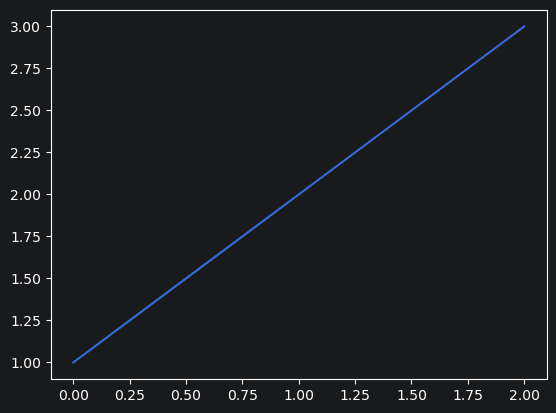

finished


In [1]:
%matplotlib inline

import matplotlib

matplotlib.rcParams['backend'] = 'module://matplotlib_inline.backend_inline'

import matplotlib.pyplot as plt

print(matplotlib.get_backend())

plt.plot([1,2,3])
plt.show()
print("finished")

In [2]:
import torch
from src.model import SequenceCNN

model = SequenceCNN()

model.load_state_dict(
    torch.load(
        "../models/liver_accessibility_cnn.pth"
    )
)

model.eval()

SequenceCNN(
  (conv1): Conv1d(4, 32, kernel_size=(11,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [3]:
import pandas as pd

dataset_df = pd.read_csv(
    "../data/processed/liver_accessibility_gc_matched.csv"
)

In [4]:
from src.datasets import SequenceDataset

dataset = SequenceDataset(
    "../data/processed/liver_accessibility_gc_matched.csv"
)

In [5]:
KERNEL_SIZE = 11
top_motifs = []

for FILTER_INDEX in range(32):
    for i in range(1000):

        sample_x, sample_y, chrom = dataset[i]

        sample_x = sample_x.unsqueeze(0)

        conv_output = model.conv1(sample_x)

        activations = (
            conv_output[
                0,
                FILTER_INDEX
            ]
            .detach()
            .numpy()
        )

        max_position = activations.argmax()

        max_activation = activations.max()

        sequence = dataset_df.iloc[i]["sequence"]

        motif_candidate = sequence[
            max_position:max_position + KERNEL_SIZE
        ]

        top_motifs.append({
            "motif": motif_candidate,
            "activation": max_activation
        })

In [6]:
top_motifs = sorted(
    top_motifs,
    key=lambda x: x["activation"],
    reverse=True
)

In [7]:
for entry in top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

GTATTACGCCA 2.1386673
GGATTACGCCA 2.07859
TTGTTACACAA 2.0348892
TGGTTATGCAA 1.9332207
CTGTGACGTGA 1.8413539
GTGTTACATAA 1.8134633
CAGTGGCGCAA 1.801694
CAGTGGCGCAA 1.801694
ACCTTGCGCAA 1.8006163
CGGTTGCGAAA 1.7908072
CTATTGCACAA 1.7853637
TTGTTACATAA 1.7710767
CTGTGGCGTAA 1.7659309
GGATTACATAA 1.7396388
GGATTGCACAA 1.7252905
ATCTTACGCAT 1.687265
GGATTGTGCAA 1.6836995
CCGTGACGCCA 1.6821688
TTGTTGCTCAA 1.6796572
ATATTGTGCAA 1.6765066


In [8]:
seen = set()

unique_top_motifs = []

for entry in top_motifs:

    motif = entry["motif"]

    if motif not in seen:

        unique_top_motifs.append(entry)

        seen.add(motif)

In [9]:
for entry in unique_top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

GTATTACGCCA 2.1386673
GGATTACGCCA 2.07859
TTGTTACACAA 2.0348892
TGGTTATGCAA 1.9332207
CTGTGACGTGA 1.8413539
GTGTTACATAA 1.8134633
CAGTGGCGCAA 1.801694
ACCTTGCGCAA 1.8006163
CGGTTGCGAAA 1.7908072
CTATTGCACAA 1.7853637
TTGTTACATAA 1.7710767
CTGTGGCGTAA 1.7659309
GGATTACATAA 1.7396388
GGATTGCACAA 1.7252905
ATCTTACGCAT 1.687265
GGATTGTGCAA 1.6836995
CCGTGACGCCA 1.6821688
TTGTTGCTCAA 1.6796572
ATATTGTGCAA 1.6765066
TTGTGATGCAA 1.6719347


In [10]:
top_sequences = [
    entry["motif"]
    for entry in unique_top_motifs[:100]
]

In [11]:
import numpy as np

pfm = np.zeros((4, KERNEL_SIZE)) #Position Frequency Matrix

nucleotide_to_index = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3
}

for sequence in top_sequences:

    for position, nucleotide in enumerate(sequence):

        row = nucleotide_to_index[
            nucleotide
        ]

        pfm[row, position] += 1

pfm = pfm / pfm.sum(axis=0)

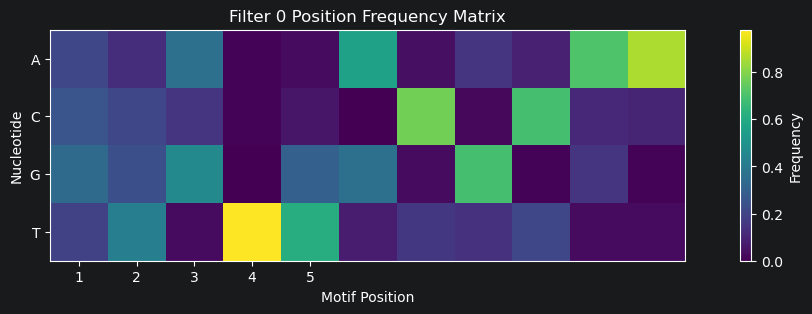

In [12]:
plt.figure(figsize=(14, 3))

plt.imshow(pfm)

plt.yticks(
    [0, 1, 2, 3],
    ["A", "C", "G", "T"]
)

plt.xticks(
    range(5),
    range(1, 6)
)

plt.xlabel("Motif Position")
plt.ylabel("Nucleotide")

plt.colorbar(label="Frequency")

plt.title("Filter 0 Position Frequency Matrix")

plt.show()

In [19]:
pwd

'C:\\Users\\dwhip\\PycharmProjects\\chromatintune\\notebooks'

In [20]:
KERNEL_SIZE = 11
top_motifs = []

nucleotide_to_index = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3
}



for FILTER_INDEX in range(32):
    for i in range(1000):

        sample_x, sample_y, chrom = dataset[i]

        sample_x = sample_x.unsqueeze(0)

        conv_output = model.conv1(sample_x)

        activations = (
            conv_output[
                0,
                FILTER_INDEX
            ]
            .detach()
            .numpy()
        )

        max_position = activations.argmax()

        max_activation = activations.max()

        sequence = dataset_df.iloc[i]["sequence"]

        motif_candidate = sequence[
            max_position:max_position + KERNEL_SIZE
        ]

        top_motifs.append({
            "motif": motif_candidate,
            "activation": max_activation
        })

    top_motifs = sorted(
    top_motifs,
    key=lambda x: x["activation"],
    reverse=True
    )

    seen = set()

    unique_top_motifs = []

    for entry in top_motifs:

        motif = entry["motif"]

        if motif not in seen:

            unique_top_motifs.append(entry)

            seen.add(motif)

    top_sequences = [
        entry["motif"]
        for entry in unique_top_motifs[:100]
    ]

    pfm = np.zeros((4, KERNEL_SIZE))

    for sequence in top_sequences:

        for position, nucleotide in enumerate(sequence):

            row = nucleotide_to_index[
                nucleotide
            ]

            pfm[row, position] += 1

    pfm = pfm / pfm.sum(axis=0)

    plt.figure(figsize=(14, 3))

    plt.imshow(pfm)

    plt.yticks(
        [0, 1, 2, 3],
        ["A", "C", "G", "T"]
    )

    plt.xticks(
        range(KERNEL_SIZE),
        range(1, KERNEL_SIZE+1)
    )

    plt.xlabel("Motif Position")
    plt.ylabel("Nucleotide")

    plt.colorbar(label="Frequency")

    plt.title(f"Filter {FILTER_INDEX} Position Frequency Matrix")

    plt.savefig(f"../figures/filter{FILTER_INDEX}")

    top_motifs = []





C:\Users\dwhip\AppData\Local\Temp\ipykernel_18180\1077823737.py:85: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14, 3))
